https://networkrepository.com/networks.php

In [25]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement seabord (from versions: none)
ERROR: No matching distribution found for seabord

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import pandas as pd

# Lettura del file
data = pd.read_csv("DD_g339.edges", sep=r"\s+", header=None, names=["from", "to"])
print(data.head())

   from  to
0     2   1
1     3   1
2     1   2
3   199   2
4     1   3


In [27]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Creazione del DataFrame
G = nx.Graph()

for index, row in data.iterrows():
    G.add_edge(row["from"], row["to"])
    
print("Nodes: ", G.nodes(data=True))
print("Edges: ", G.edges())

# Grado medio
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

print("Average degree: ", avg_degree)

Nodes:  [(2, {}), (1, {}), (3, {}), (199, {}), (96, {}), (239, {}), (5, {}), (4, {}), (6, {}), (7, {}), (8, {}), (109, {}), (262, {}), (263, {}), (9, {}), (10, {}), (11, {}), (30, {}), (231, {}), (13, {}), (12, {}), (14, {}), (15, {}), (16, {}), (17, {}), (147, {}), (195, {}), (216, {}), (252, {}), (253, {}), (282, {}), (19, {}), (18, {}), (20, {}), (275, {}), (21, {}), (281, {}), (111, {}), (23, {}), (22, {}), (24, {}), (25, {}), (26, {}), (61, {}), (64, {}), (70, {}), (187, {}), (271, {}), (28, {}), (27, {}), (29, {}), (82, {}), (84, {}), (164, {}), (165, {}), (31, {}), (32, {}), (34, {}), (33, {}), (35, {}), (36, {}), (230, {}), (156, {}), (157, {}), (38, {}), (37, {}), (39, {}), (40, {}), (41, {}), (155, {}), (217, {}), (222, {}), (224, {}), (237, {}), (260, {}), (110, {}), (218, {}), (229, {}), (202, {}), (258, {}), (43, {}), (42, {}), (44, {}), (45, {}), (46, {}), (108, {}), (47, {}), (51, {}), (52, {}), (59, {}), (60, {}), (48, {}), (49, {}), (50, {}), (81, {}), (106, {}), (107,

In [28]:
# Calcolo delle caratteristiche del grafo

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
connected = nx.is_connected(G)
avg_clustering = nx.average_clustering(G)

if connected:
    radius = nx.radius(G)
    diameter = nx.diameter(G)
    periphery = nx.periphery(G)
else:
    radius = None
    diameter = None
    periphery = None

print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Density: {density}")
print(f"Connected: {connected}")
    
if connected:
    print(f"Radius: {radius}")
    print(f"Diameter: {diameter}")
    print(f"Periphery: {periphery}")
else:
    print("Radius, diameter and periphery are not defined for disconnected graphs.")
    
print(f"Average clustering coefficient: {avg_clustering}")

Number of nodes: 282
Number of edges: 631
Density: 0.01592589788243608
Connected: True
Radius: 11
Diameter: 22
Periphery: [54, 56, 276]
Average clustering coefficient: 0.47314814814814815


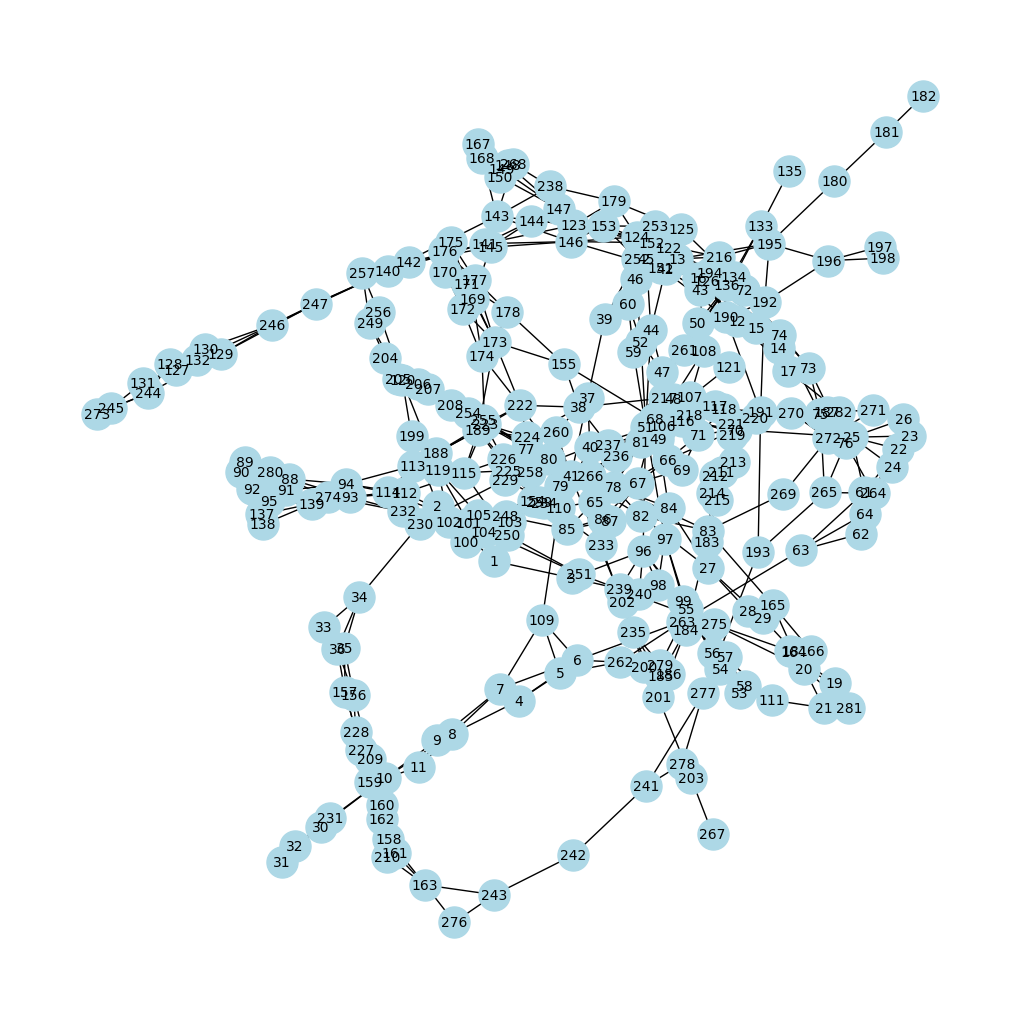

In [29]:
# Visualizzazione Spring
pos = nx.spring_layout(G)
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_size=500, node_color = 'lightblue', font_size=10)
plt.show()

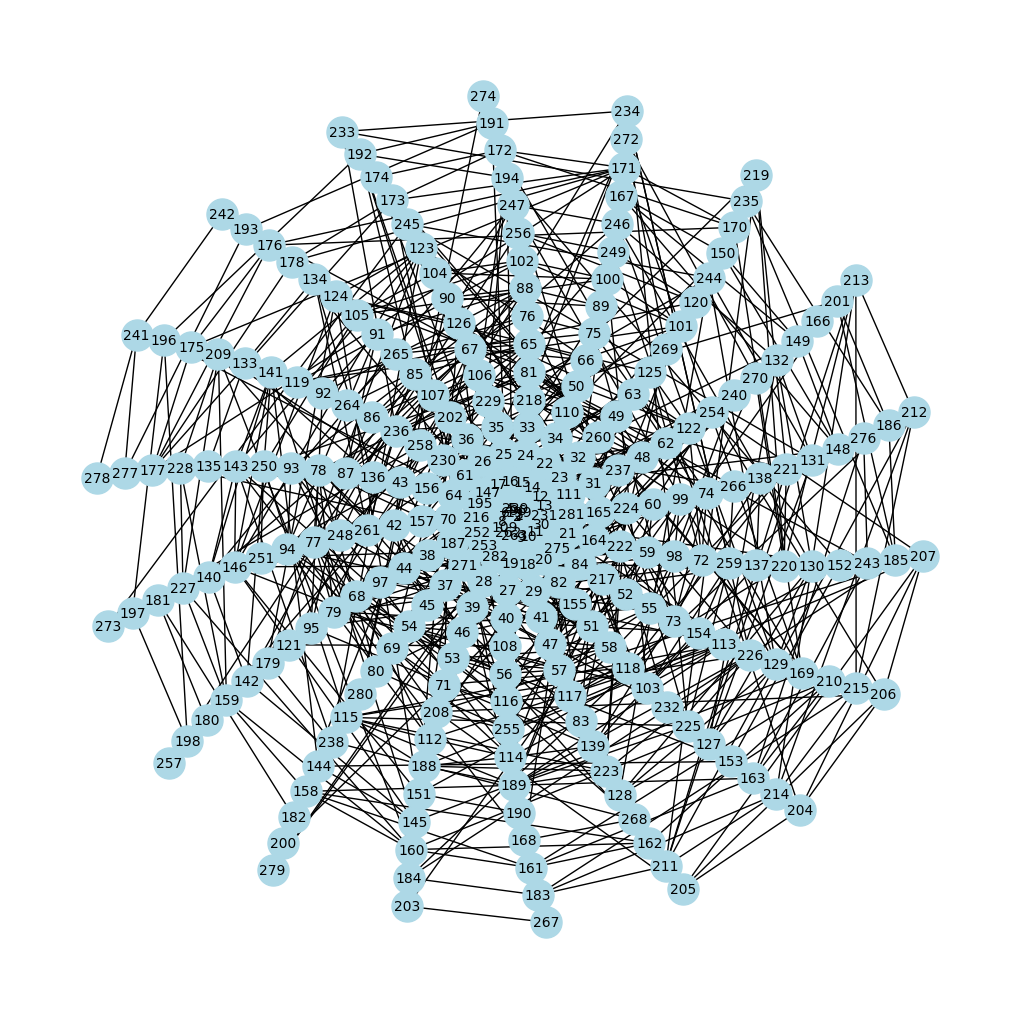

In [30]:
# Visualizzazione Spiral
pos = nx.spiral_layout(G)

plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_size=500, node_color = 'lightblue', font_size=10)
plt.show()

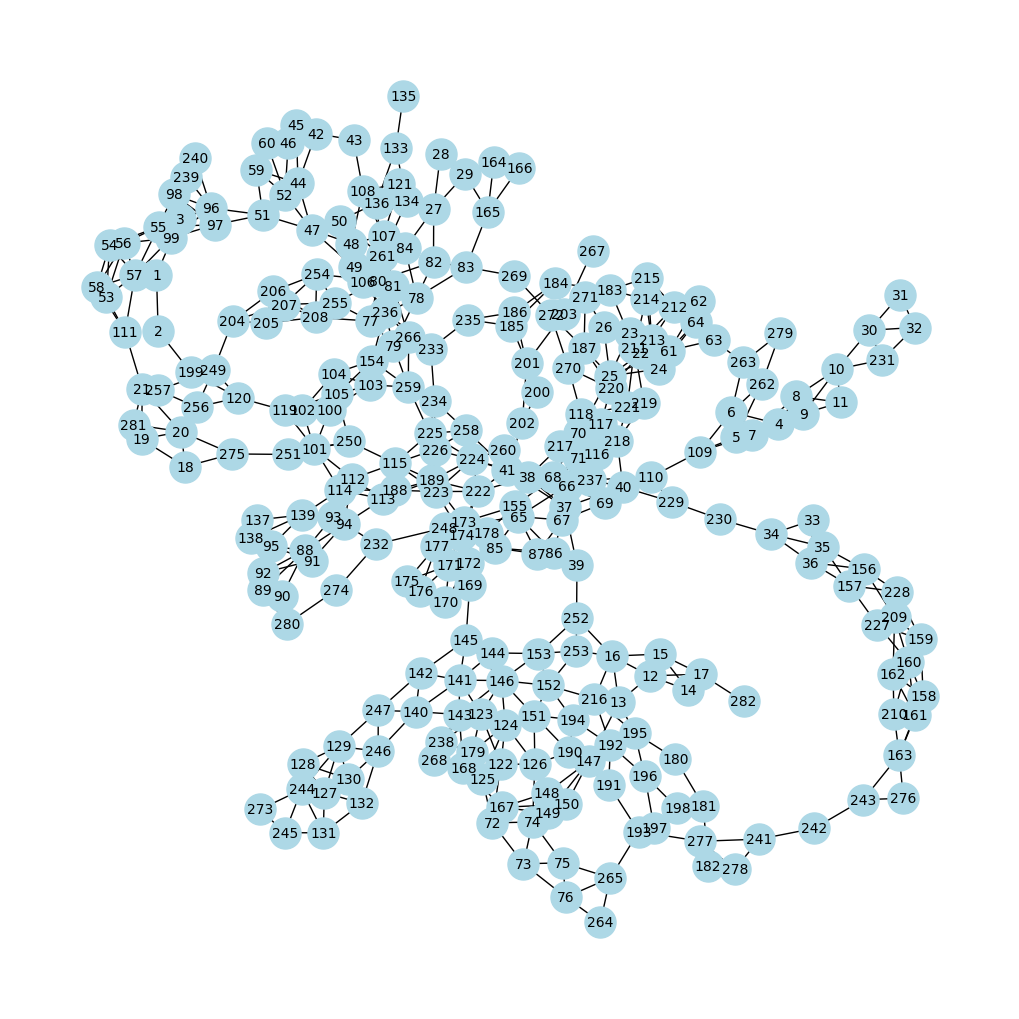

In [31]:
# Visualizzazione Kamada-Kawai
pos = nx.kamada_kawai_layout(G)

plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, node_size=500, node_color = 'lightblue', font_size=10)
plt.show()

### Analisi delle Centrality

In [46]:
# Calcolo delle centrality
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigen_centrality = nx.eigenvector_centrality(G)

centrality_df = pd.DataFrame({
    "Node": list(G.nodes()),
    "Degree Centrality": [degree_centrality[node] for node in G.nodes()],
    "Closeness Centrality": [closeness_centrality[node] for node in G.nodes()],
    "Betweenness Centrality": [betweenness_centrality[node] for node in G.nodes()],
    "Eigen Centrality": [eigen_centrality[node] for node in G.nodes()]
})

sorted_centrality_df = centrality_df.copy()
sorted_centrality_df["Node"] = sorted_centrality_df["Node"].astype(str)

sorted_degree = sorted_centrality_df.sort_values(by=["Degree Centrality"], ascending=False)
sorted_closeness = sorted_centrality_df.sort_values(by=["Closeness Centrality"], ascending=False)
sorted_betweenness = sorted_centrality_df.sort_values(by=["Betweenness Centrality"], ascending=False)
sorted_eigen = sorted_centrality_df.sort_values(by=["Eigen Centrality"], ascending=False)

In [47]:
print("Top 5 Degree Centrality:\n", sorted_degree.head(), "\n")
print("Bottom 5 Degree Centrality:\n", sorted_degree.tail(), "\n")

print("Top 5 Closeness Centrality:\n", sorted_closeness.head(), "\n")
print("Bottom 5 Closeness Centrality:\n", sorted_closeness.tail(), "\n")

print("Top 5 Betweenness Centrality:\n", sorted_betweenness.head(), "\n")
print("Bottom 5 Betweenness Centrality:\n", sorted_betweenness.tail(), "\n")

print("Top 5 Eigen Centrality:\n", sorted_eigen.head(), "\n")
print("Bottom 5 Eigen Centrality:\n", sorted_eigen.tail(), "\n")

Top 5 Degree Centrality:
     Node  Degree Centrality  Closeness Centrality  Betweenness Centrality  \
221  173           0.032028              0.167861                0.207662   
72   224           0.032028              0.167362                0.099029   
175  189           0.032028              0.169481                0.192109   
237  171           0.028470              0.150027                0.011362   
97   236           0.028470              0.139316                0.137255   

     Eigen Centrality  
221          0.199943  
72           0.315760  
175          0.359466  
237          0.104889  
97           0.026586   

Bottom 5 Degree Centrality:
     Node  Degree Centrality  Closeness Centrality  Betweenness Centrality  \
243  181           0.007117              0.091501                0.007117   
206  135           0.003559              0.091680                0.000000   
265  267           0.003559              0.105047                0.000000   
30   282           0.003559 

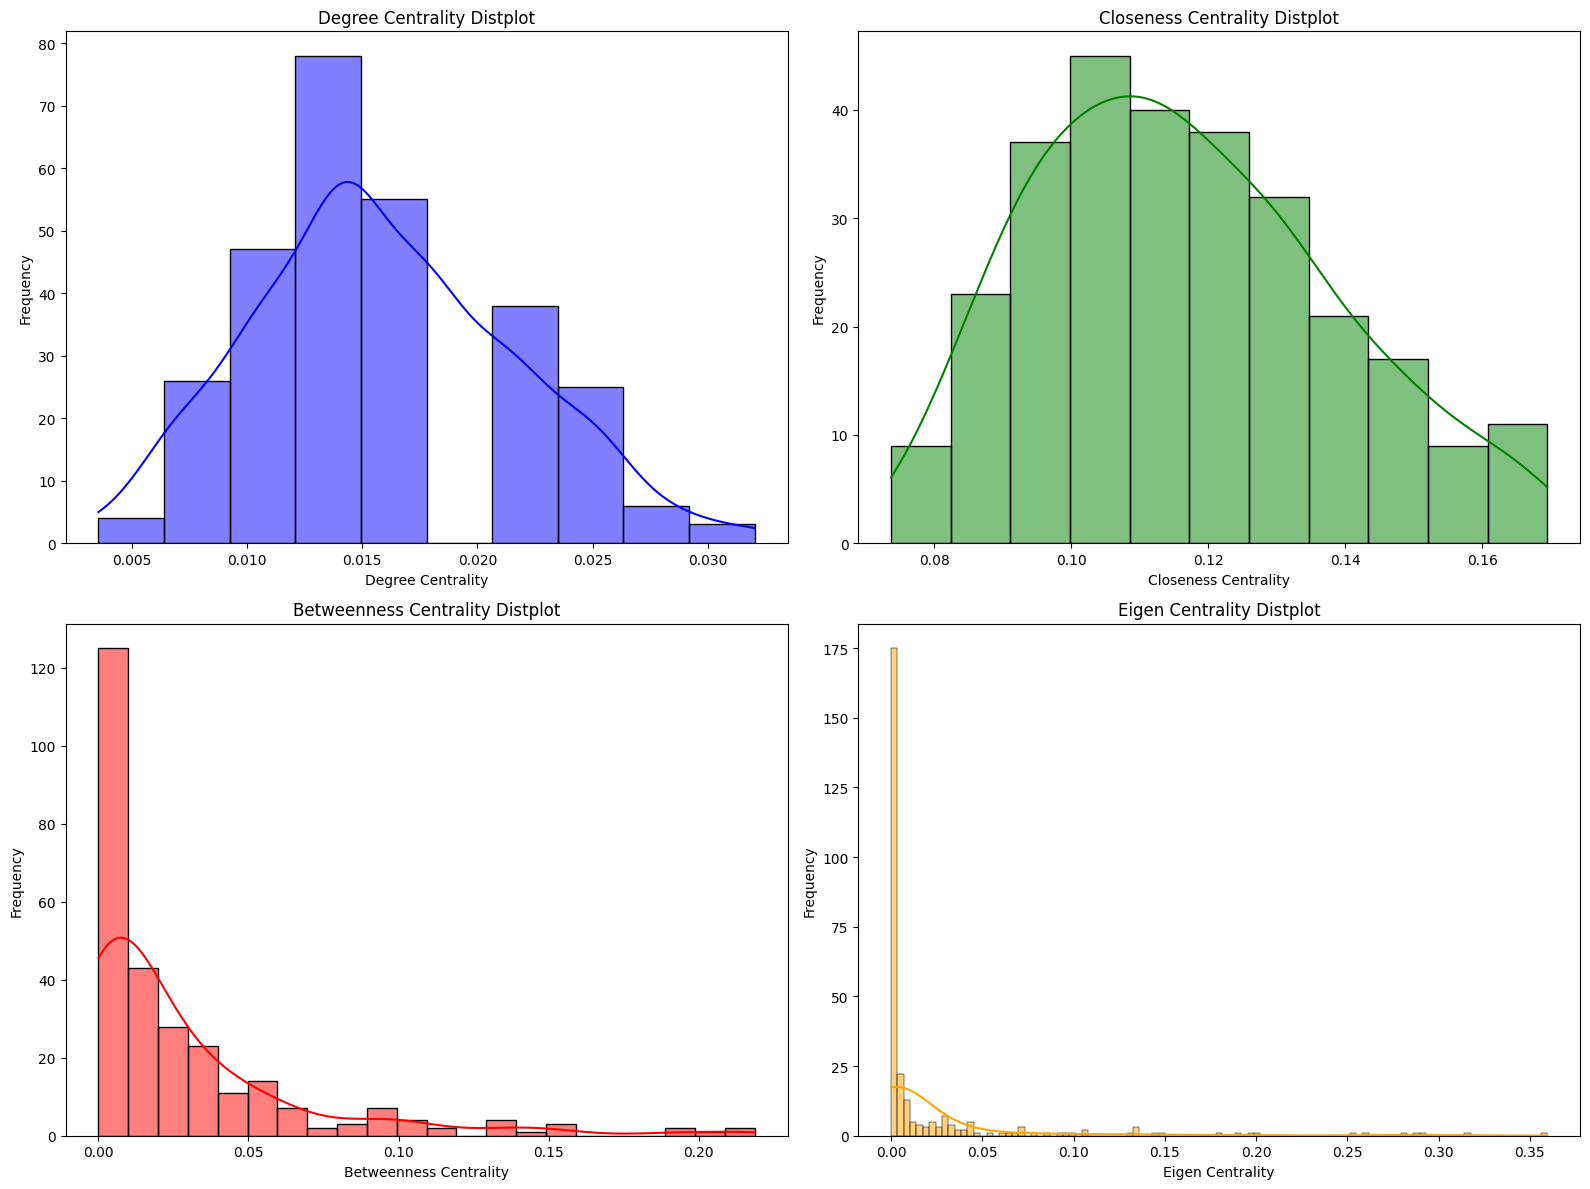

In [48]:
import seaborn as sns

# Visualizzazione delle Centrality
plt.figure(figsize=(16, 12))

# Degree Centrality Distplot
plt.subplot(2,2,1)
sns.histplot(sorted_degree["Degree Centrality"], kde=True, color='blue')
plt.title("Degree Centrality Distplot")
plt.xlabel("Degree Centrality")
plt.ylabel("Frequency")

# Closeness Centrality Distplot
plt.subplot(2,2,2)
sns.histplot(sorted_closeness["Closeness Centrality"], kde=True, color='green')
plt.title("Closeness Centrality Distplot")
plt.xlabel("Closeness Centrality")
plt.ylabel("Frequency")

# Betweenness Centrality Distplot
plt.subplot(2,2,3)
sns.histplot(sorted_betweenness["Betweenness Centrality"], kde=True, color='red')
plt.title("Betweenness Centrality Distplot")
plt.xlabel("Betweenness Centrality")
plt.ylabel("Frequency")

# Eigen Centrality Distplot
plt.subplot(2,2,4)
sns.histplot(sorted_eigen["Eigen Centrality"], kde=True, color='orange')
plt.title("Eigen Centrality Distplot")
plt.xlabel("Eigen Centrality")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


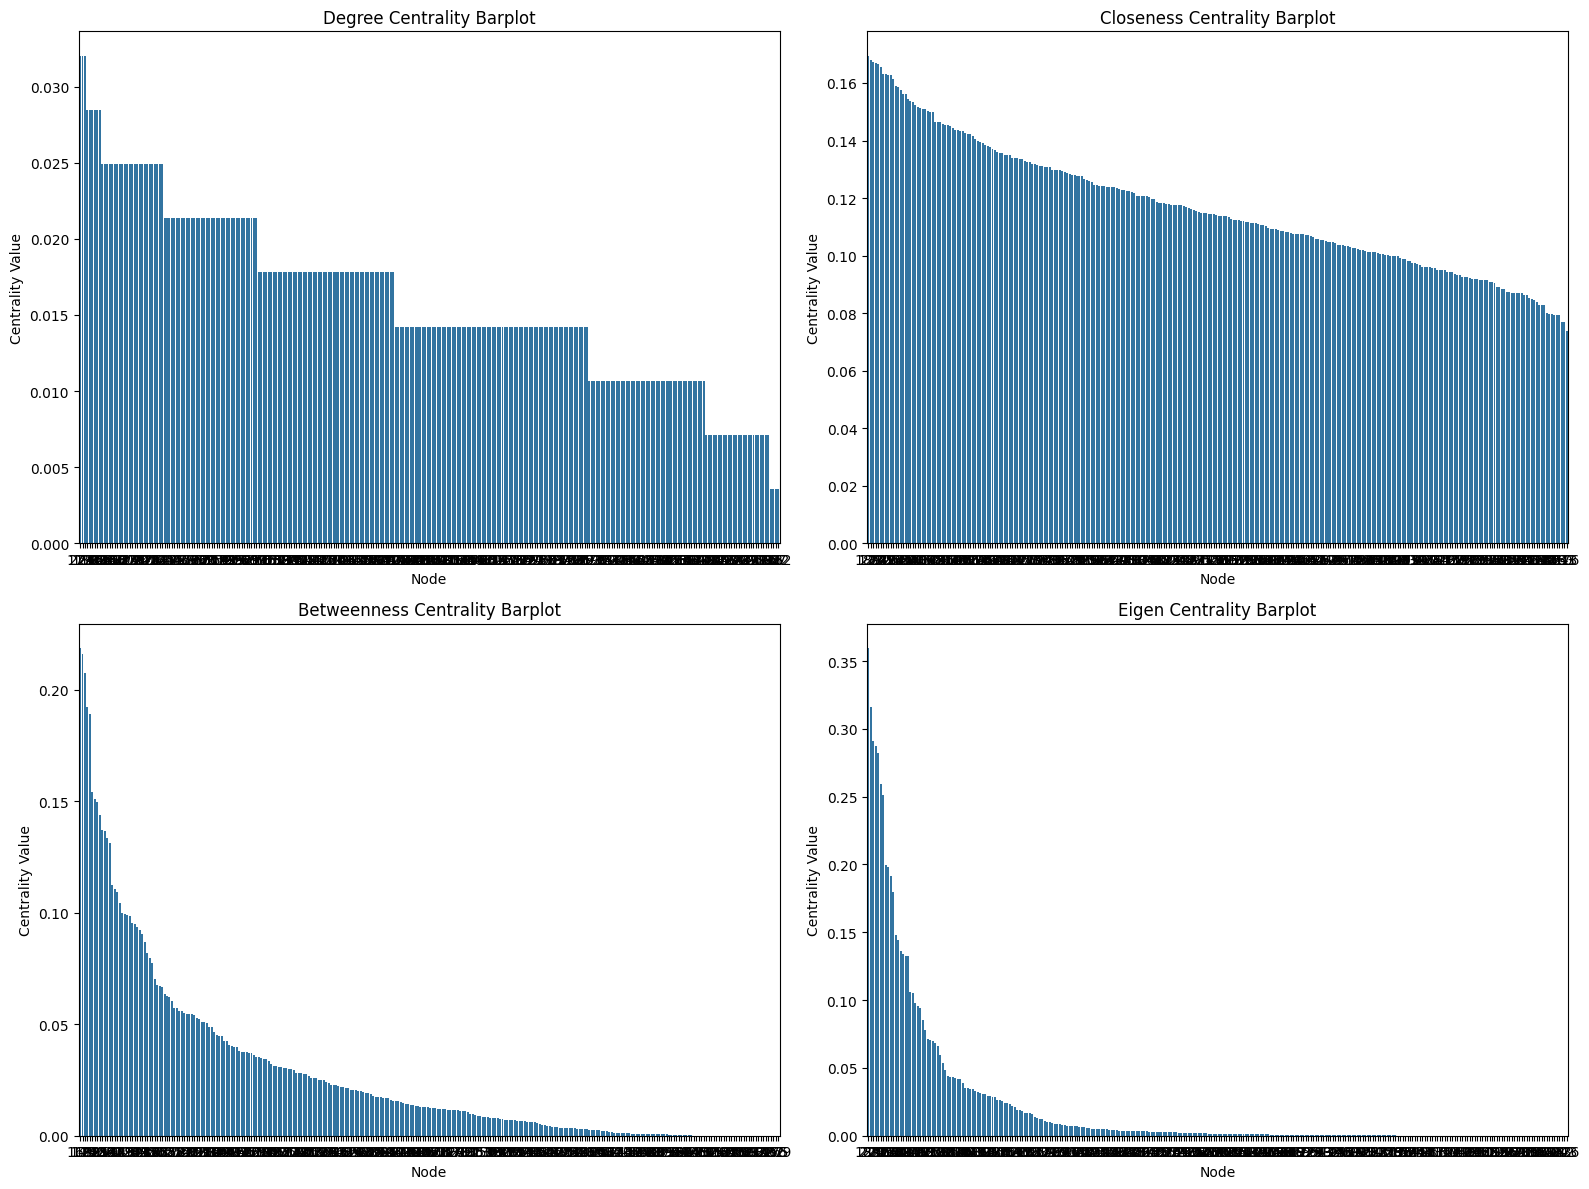

In [49]:
plt.figure(figsize=(16, 12))

# Degree Centrality Barplot
plt.subplot(2,2,1)
sns.barplot(x="Node", y="Degree Centrality", data=sorted_degree)
plt.title("Degree Centrality Barplot")
plt.xlabel("Node")
plt.ylabel("Centrality Value")

# Closeness Centrality Barplot
plt.subplot(2,2,2)
sns.barplot(x="Node", y="Closeness Centrality", data=sorted_closeness)
plt.title("Closeness Centrality Barplot")
plt.xlabel("Node")
plt.ylabel("Centrality Value")

# Betweenness Centrality Barplot
plt.subplot(2,2,3)
sns.barplot(x="Node", y="Betweenness Centrality", data=sorted_betweenness)
plt.title("Betweenness Centrality Barplot")
plt.xlabel("Node")
plt.ylabel("Centrality Value")

# Eigen Centrality Barplot
plt.subplot(2,2,4)
sns.barplot(x="Node", y="Eigen Centrality", data=sorted_eigen)
plt.title("Eigen Centrality Barplot")
plt.xlabel("Node")
plt.ylabel("Centrality Value")

plt.tight_layout()
plt.show()

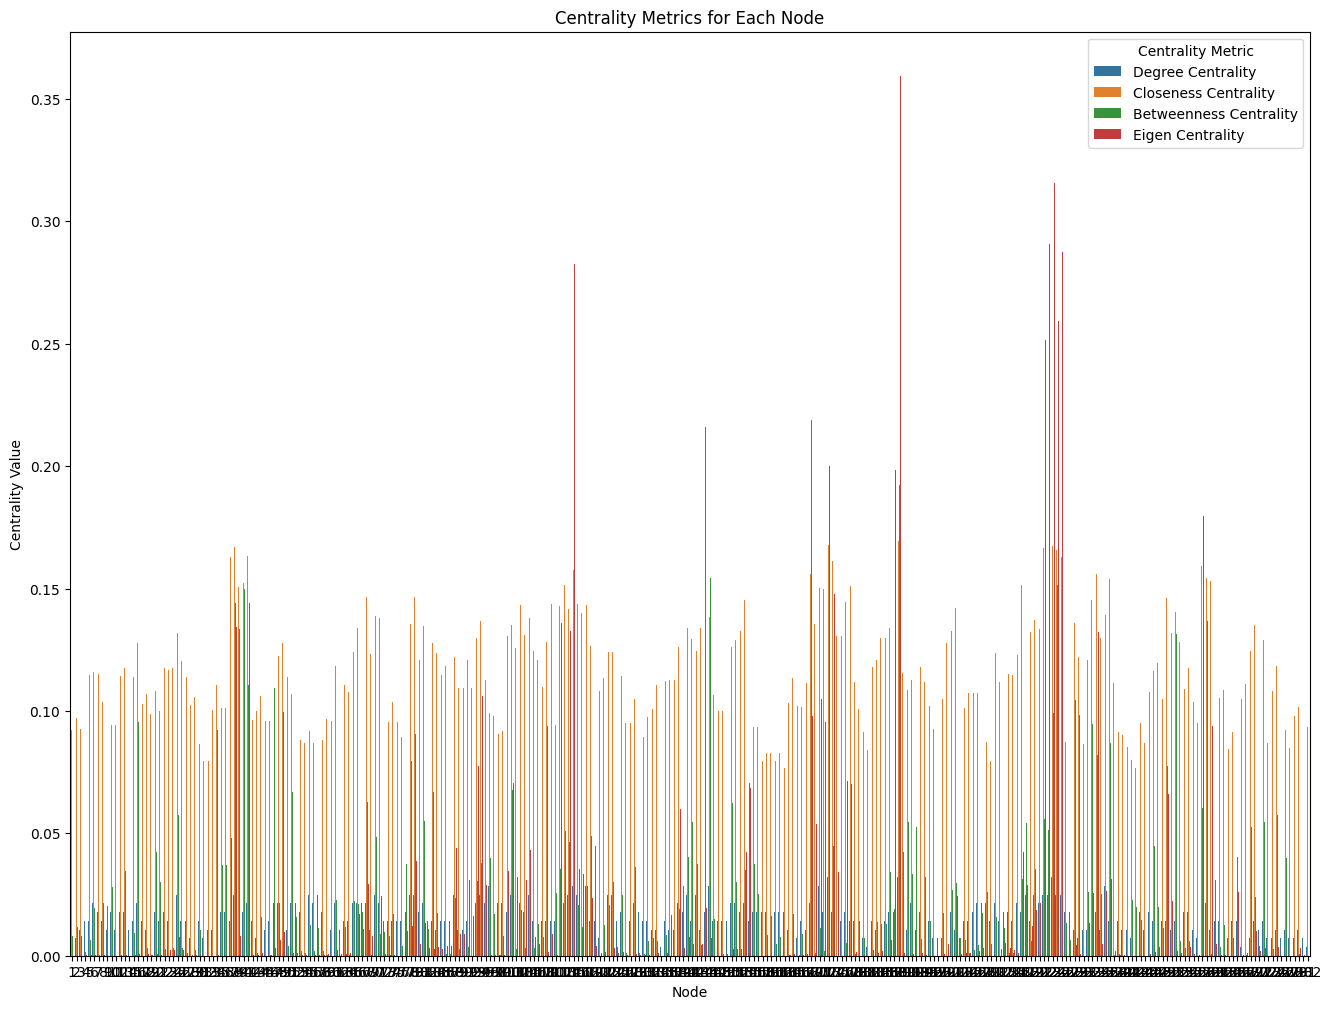

In [ ]:
# Visualizzazione delle Centrality per ogni nodo
plt.figure(figsize=(16, 12))
sns.barplot(data=pd.melt(centrality_df, id_vars="Node", var_name="Centrality Metric", value_name="Value"),
            x="Node", y="Value", hue="Centrality Metric")
plt.title("Centrality Metrics for Each Node")
plt.xlabel("Node")
plt.ylabel("Centrality Value")
plt.legend(title="Centrality Metric")
plt.show()

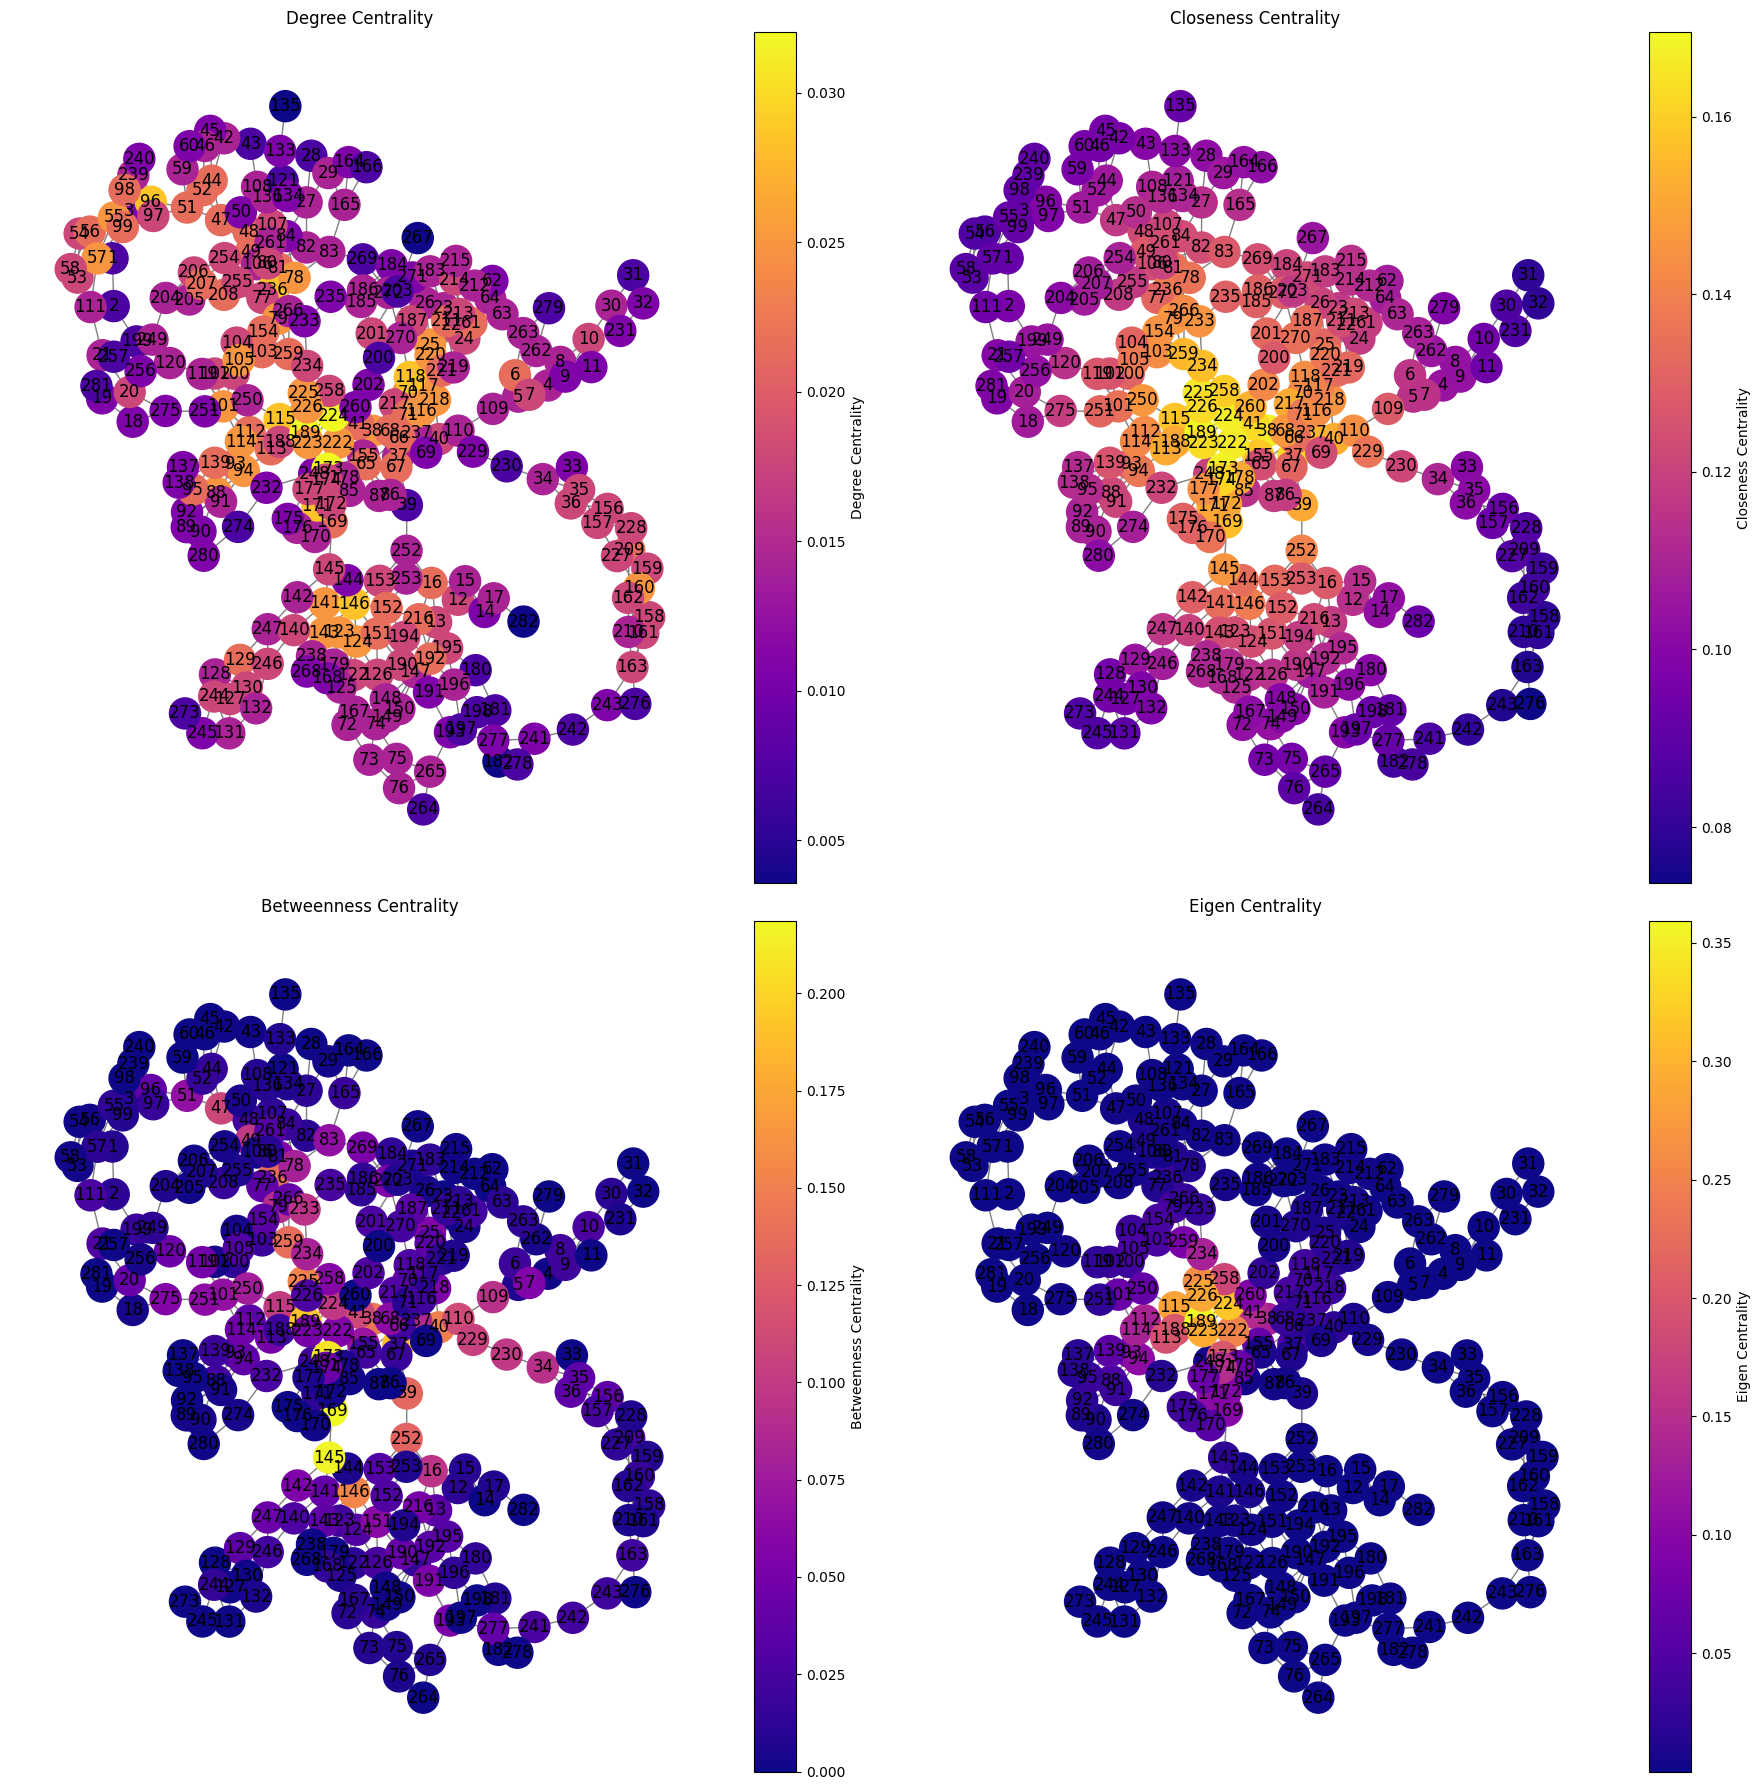

In [ ]:
plt.figure(figsize=(18, 18))

# Degree Centrality Scatterplot
plt.subplot(2,2,1)
node_color = [degree_centrality[node] for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_size=500, node_color = node_color, cmap='plasma', edge_color="gray")
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(node_color), vmax=max(node_color)))
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label="Degree Centrality")
plt.title("Degree Centrality")

# Closeness Centrality Scatterplot
plt.subplot(2,2,2)
node_color = [closeness_centrality[node] for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_size=500, node_color = node_color, cmap='plasma', edge_color="gray")
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(node_color), vmax=max(node_color)))
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label="Closeness Centrality")
plt.title("Closeness Centrality")

# Betweenness Centrality Scatterplot
plt.subplot(2,2,3)
node_color = [betweenness_centrality[node] for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_size=500, node_color = node_color, cmap='plasma', edge_color="gray")
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(node_color), vmax=max(node_color)))
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label="Betweenness Centrality")
plt.title("Betweenness Centrality")

# Eigen Centrality Scatterplot
plt.subplot(2,2,4)
node_color = [eigen_centrality[node] for node in G.nodes()]
nx.draw(G, pos, with_labels=True, node_size=500, node_color = node_color, cmap='plasma', edge_color="gray")
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=min(node_color), vmax=max(node_color)))
sm.set_array([])
plt.colorbar(sm, ax=plt.gca(), label="Eigen Centrality")
plt.title("Eigen Centrality")

plt.tight_layout()
plt.show()

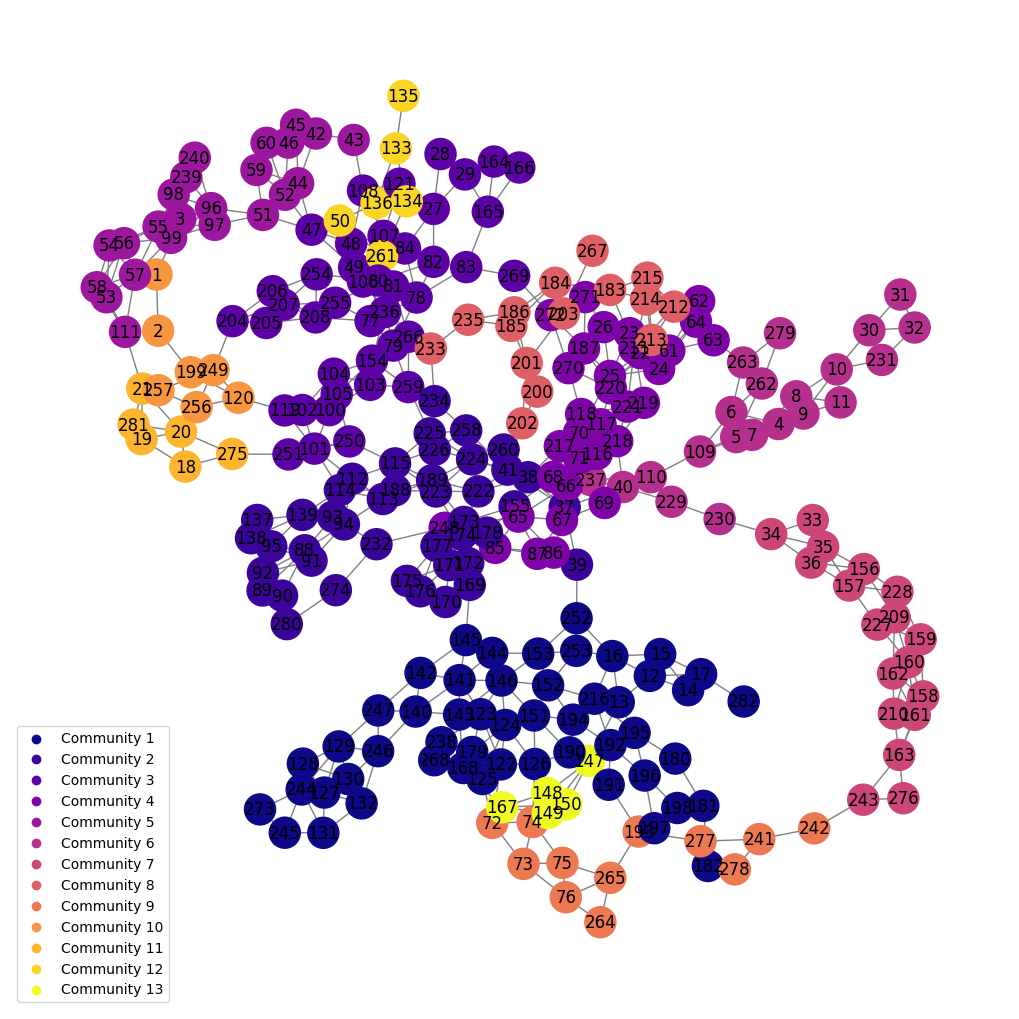

In [52]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G))

community_colors = plt.cm.plasma(np.linspace(0, 1, len(communities)))
node_color = {}

for i, community in enumerate(communities):
    for node in community:
        node_color[node] = community_colors[i]


colors = [node_color[node] for node in G.nodes]


plt.figure(figsize=(10, 10))

nx.draw(G, pos, node_color=colors, with_labels=True, node_size=500, edge_color="gray")


for i, community in enumerate(communities):
    plt.scatter([], [], color=community_colors[i], label=f'Community {i+1}')

plt.legend()

plt.show()


In [53]:

cliques = list(nx.find_cliques(G))

triadic_closures = nx.triangles(G)


k_core_dict = {}
for k in range(1, max(dict(G.degree()).values()) + 1):
    k_core = nx.k_core(G, k=k)
    if k_core.number_of_nodes() > 0:
        k_core_dict[k] = k_core


clique_count = len(cliques)
triadic_closures_count = sum(triadic_closures.values()) // 3  # ogni triangolo viene contato tre volte
k_core_summary = {k: len(core.nodes) for k, core in k_core_dict.items()}

print('Clique: ', clique_count)
print('Triadic_closures: ', triadic_closures_count) 
print('k_core: ', k_core_summary) 


Clique:  284
Triadic_closures:  379
k_core:  {1: 282, 2: 275, 3: 211, 4: 30}


In [54]:

max_clique_size = max(len(clique) for clique in cliques)
largest_cliques = [clique for clique in cliques if len(clique) == max_clique_size]


max_k = max(k_core_dict.keys())
largest_k_core = k_core_dict[max_k]

ego_node = 19 # Sostituisci con l'id di un nodo
ego_network = nx.ego_graph(G, ego_node)  


print("Largest cliques:",largest_cliques)
print("Max k:", max_k)
print("Nodes of the largest k core:",list(largest_k_core.nodes))
print("Ego-network of node:", ego_node, ":", ego_network)

Largest cliques: [[53, 57, 58, 56, 54], [55, 99, 96, 97, 98]]
Max k: 4
Nodes of the largest k core: [258, 259, 154, 53, 54, 55, 56, 57, 58, 188, 189, 223, 96, 224, 97, 98, 99, 101, 100, 103, 102, 104, 105, 226, 234, 225, 112, 113, 114, 115]
Ego-network of node: 19 : Graph with 4 nodes and 5 edges
